In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.impute import SimpleImputer
import torch
import torch.nn as nn
import torch.optim as opt

In [ ]:
dataset = pd.read_csv('titanic.csv')
dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
print(dataset["Survived"].unique())
print(dataset["Survived"].value_counts())

[0 1]
Survived
0    549
1    342
Name: count, dtype: int64


In [ ]:
dataset.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
age_impute = SimpleImputer(strategy = 'mean')
dataset['Age'] = age_impute.fit_transform(dataset[['Age']])

embarked_impute = SimpleImputer(strategy = 'most_frequent')
dataset['Embarked'] = embarked_impute.fit_transform(dataset[['Embarked']]).ravel()

In [ ]:
dataset.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
labelencode = LabelEncoder()
dataset["Sex"] = labelencode.fit_transform(dataset["Sex"])
dataset["Embarked"] = labelencode.fit_transform(dataset["Embarked"])
dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,NaN,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.000000,0,0,211536,13.0000,NaN,2
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.000000,0,0,112053,30.0000,B42,2
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,29.699118,1,2,W./C. 6607,23.4500,NaN,2
889,890,1,1,"Behr, Mr. Karl Howell",1,26.000000,0,0,111369,30.0000,C148,0


In [ ]:
dataset.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis = 1, inplace = True)
dataset

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.000000,1,0,7.2500,2
1,1,1,0,38.000000,1,0,71.2833,0
2,1,3,0,26.000000,0,0,7.9250,2
3,1,1,0,35.000000,1,0,53.1000,2
4,0,3,1,35.000000,0,0,8.0500,2
...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,2
887,1,1,0,19.000000,0,0,30.0000,2
888,0,3,0,29.699118,1,2,23.4500,2
889,1,1,1,26.000000,0,0,30.0000,0


In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)
dataset = pd.DataFrame(scaled_data, columns = dataset.columns)
dataset

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,-0.789272,0.827377,0.737695,-0.592481,0.432793,-0.473674,-0.502445,0.585954
1,1.266990,-1.566107,-1.355574,0.638789,0.432793,-0.473674,0.786845,-1.942303
2,1.266990,0.827377,-1.355574,-0.284663,-0.474545,-0.473674,-0.488854,0.585954
3,1.266990,-1.566107,-1.355574,0.407926,0.432793,-0.473674,0.420730,0.585954
4,-0.789272,0.827377,0.737695,0.407926,-0.474545,-0.473674,-0.486337,0.585954
...,...,...,...,...,...,...,...,...
886,-0.789272,-0.369365,0.737695,-0.207709,-0.474545,-0.473674,-0.386671,0.585954
887,1.266990,-1.566107,-1.355574,-0.823344,-0.474545,-0.473674,-0.044381,0.585954
888,-0.789272,0.827377,-1.355574,0.000000,0.432793,2.008933,-0.176263,0.585954
889,1.266990,-1.566107,0.737695,-0.284663,-0.474545,-0.473674,-0.044381,-1.942303


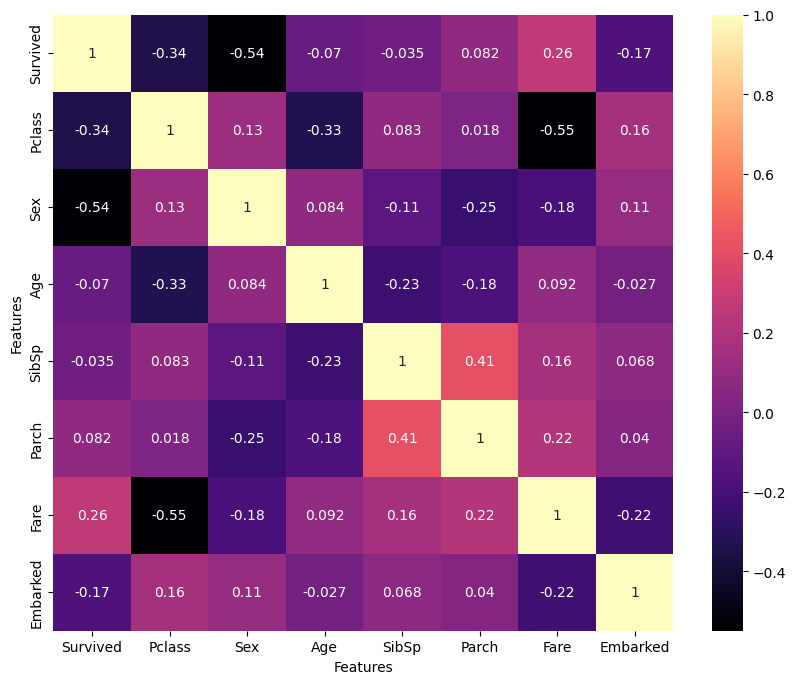

In [ ]:
correlation_matrix = dataset.corr()
plt.figure(figsize = (10, 8))
sns.heatmap(correlation_matrix, annot = True, cmap = 'magma')
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

In [ ]:
X = dataset.drop(["Survived"], axis = 1)
y = dataset["Survived"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)
Y_train = torch.tensor(Y_train.values, dtype = torch.long)
Y_test = torch.tensor(Y_test.values, dtype = torch.long)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

torch.Size([712, 7])
torch.Size([179, 7])
torch.Size([712])
torch.Size([179])


In [ ]:
class neural_network(nn.Module):
  def __init__(self):
    super(neural_network, self).__init__()
    self.layer1 = nn.Linear(7, 50)
    self.layer2 = nn.Linear(50, 50)
    self.layer3 = nn.Linear(32, 16)
    self.layer4 = nn.Linear(50, 2)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.2)

  def forward(self, X):
    output = self.layer1(X)
    output = self.relu(output)
    output = self.dropout(output)
    output = self.layer2(output)
    output = self.relu(output)
    output = self.dropout(output)
    output = self.layer3(output)
    output = self.relu(output)
    output = self.dropout(output)
    output = self.layer4(output)
    return output

DL_Model = neural_network()

In [ ]:
loss_function = nn.CrossEntropyLoss()
optimizer = opt.Adam(DL_Model.parameters(), lr = 0.01)

In [ ]:
epoch = 500
for ep in range(epoch):
  Output = DL_Model(X_train)
  loss = loss_function(Output, Y_train)

  if ep % 10 == 0:
    print("Epoch: ", ep, "Loss: ", loss.item())

  loss.backward()
  optimizer.step()
  optimizer.zero_grad()

Epoch:  0 Loss:  0.695112943649292
Epoch:  10 Loss:  0.457819402217865
Epoch:  20 Loss:  0.4211018681526184
Epoch:  30 Loss:  0.396223783493042
Epoch:  40 Loss:  0.40482816100120544
Epoch:  50 Loss:  0.3793838918209076
Epoch:  60 Loss:  0.37122371792793274
Epoch:  70 Loss:  0.37915849685668945
Epoch:  80 Loss:  0.3628484010696411
Epoch:  90 Loss:  0.35091498494148254
Epoch:  100 Loss:  0.34994229674339294
Epoch:  110 Loss:  0.35275113582611084
Epoch:  120 Loss:  0.34733253717422485
Epoch:  130 Loss:  0.3482356071472168
Epoch:  140 Loss:  0.3469544053077698
Epoch:  150 Loss:  0.33298778533935547
Epoch:  160 Loss:  0.3417361080646515
Epoch:  170 Loss:  0.32877299189567566
Epoch:  180 Loss:  0.3564213216304779
Epoch:  190 Loss:  0.3363064229488373
Epoch:  200 Loss:  0.34007397294044495
Epoch:  210 Loss:  0.32443103194236755
Epoch:  220 Loss:  0.32470187544822693
Epoch:  230 Loss:  0.3267224133014679
Epoch:  240 Loss:  0.31498607993125916
Epoch:  250 Loss:  0.31892701983451843
Epoch:  260 

In [ ]:
#accuracy
with torch.no_grad():
  Output = DL_Model(X_test)
  _, predicted = torch.max(Output.data, 1)
  accuracy = (predicted == Y_test).sum()/len(Y_test)
  print("Accuracy: ", accuracy.item())

Accuracy:  0.8044692873954773


In [ ]:
print(DL_Model)

neural_network(
  (layer1): Linear(in_features=7, out_features=50, bias=True)
  (layer2): Linear(in_features=50, out_features=50, bias=True)
  (layer4): Linear(in_features=50, out_features=2, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)


In [ ]:
#classification report
cr = classification_report(Y_test, predicted)
print(cr)

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       105
           1       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



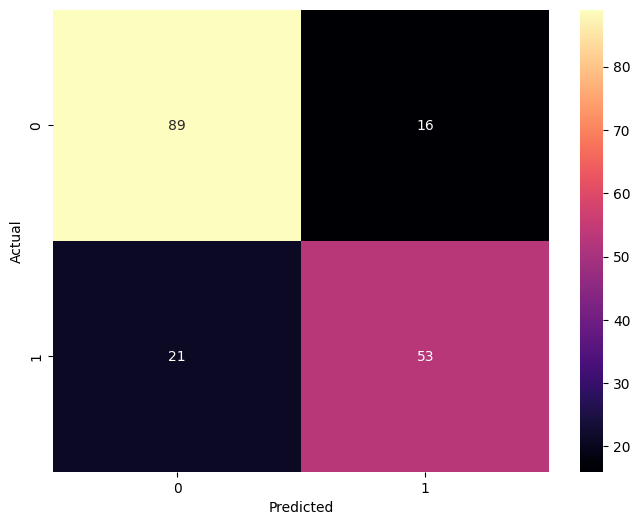

In [ ]:
#confusion matrix
cm = confusion_matrix(Y_test, predicted)
plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, cmap = 'magma')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()